In [1]:
import numpy as np
import math
from matplotlib import pyplot as plt
import sys
np.set_printoptions(threshold=sys.maxsize)

from src.initial_data import initial_data
from src.integrators import solve_ODE
from src.error import wass_2_approx

# Configuration


In [2]:
m = 100

h = .005
moll_eps = 4 * h**(.99)
xi_eps = 8 * h**(.99)

t_max = 1.5
t_step = 3 * 10**(-4)

# Parameters for random blob methods
alg = 2
num_batches = 2
ratio = 2

# Function definitions


In [3]:
# The external potential
def V(x):
    return x**2 / 2

# Gradient of velocity field
def grad_V(x):
    return x
    
# Distribution of our initial data
def rho_0(x):
    return np.where(-1.5 <= x and x <= 1.5, 1/3, 0)

# 2nd derivative of Moreau-Yosida envelope
def f_double_prime_epsilon(x):
    return m * x**(m - 2)

# Constant so that the integral of rho_infty equals 1
def normalizing_const():
    if 20 < m < 800:
        return .127

# Our functions should converge to this function over time
def rho_infty(x):
    z = normalizing_const()
    if m == 1:
        return np.exp(z - V(x))
    if m < math.inf:
        m_prime = m / (m - 1)
        return np.maximum(0, (z - V(x))/m_prime)**(m_prime - 1)

# Plot


In [4]:
def xi(x):
    denom = (2 * np.pi * (xi_eps**2))**(1 / 2)
    arg = - (x**2) / (2 * (xi_eps**2))
    return np.exp(arg) / denom

def smooth(input, m_vals, part_sol):
    return np.dot(xi(input[:, None] - part_sol), m_vals)

def plot(particle_sol, m_vals, num_steps = 7):
    plt.rcParams.update({'font.size': 20})
    plt.rcParams['text.usetex'] = True
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    x_vals = np.arange(- 3.5, 3.5, .01)
    colors = plt.cm.viridis(np.linspace(0, 1, num_steps))
    jump_size = int(particle_sol.shape[0] / (num_steps - 1))

    # Plot particles BEFORE final time
    for i in range(num_steps - 1):
        y_vals = smooth(x_vals, m_vals, particle_sol[i * jump_size])
        lab = rf'$t = {round(t_max * (jump_size / particle_sol.shape[0]) * i, 3)}$'
        plt.plot(x_vals, y_vals, '--', linewidth=5, label = lab, color = colors[i])

    # Plot final step
    y_vals = smooth(x_vals, m_vals, particle_sol[-1])
    lab = rf'$t = {round(t_max, 2)}$'
    plt.plot(x_vals, y_vals, '--', linewidth=5, label = lab, color = colors[-1])

    y_vals = rho_infty(x_vals)
    lab = r'$t = \infty$'
    plt.plot(x_vals, y_vals, color = '#fc036f', label = lab, linewidth = 2)
    
    plt.xlabel("Position")
    plt.ylabel("Height")
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.ylim(0, 1.2)
    plt.xlim(-2, 2)
    plt.show()

# Main method


N = 601.
Time step 1000.
Time step 2000.
Time step 3000.
Time step 4000.
--- 13.320158958435059 seconds ---


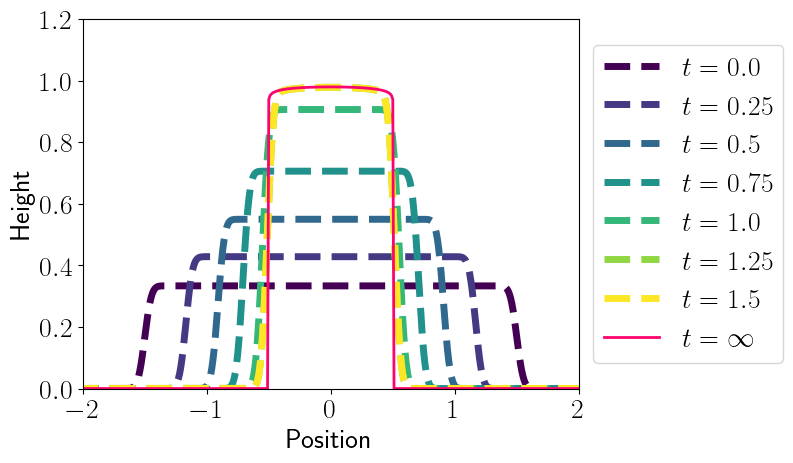

Error = 0.007815607419895843.


In [5]:
x0, m_vals = initial_data(rho_0, 1.6, h)
part_sol, runtime = solve_ODE(x0, m_vals, alg, ratio, num_batches, moll_eps, f_double_prime_epsilon, grad_V, t_step, t_max, 3)
plot(part_sol, m_vals)

error = wass_2_approx(part_sol[-1], m_vals, rho_infty, 1.02, .005)
print("Error = " + str(error) + ".")